# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** Muhammad Zulfikar
- **Email:** masfikar92@gmail.com(CDCC466D6Y1391@student.devacademy.id)
- **ID Dicoding:** CDCC466D6Y1391

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Pada bulan apa penyewaan sepeda paling tinggi dan paling rendah selama periode 2011-2012, untuk merencanakan strategi promosi pada bulan-bulan dengan penyewaan rendah?
- **Pertanyaan 2:** Seberapa besar pengaruh suhu yang dirasakan tubuh (atemp) terhadap jumlah penyewaan sepeda pada periode 2011-2012, untuk menentukan strategi promosi dan operasional berdasarkan kondisi cuaca?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load Dataset

Dataset yang digunakan adalah **Bike Sharing Dataset** yang terdiri dari dua file:
- `day.csv` — data agregat harian (731 baris)
- `hour.csv` — data per jam (17.379 baris)

Keduanya memiliki kolom yang hampir sama, perbedaannya `hour.csv` memiliki kolom tambahan `hr` (jam 0–23).

In [2]:
df_day = pd.read_csv('day.csv')
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
df_hour = pd.read_csv('hour.csv')
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight Gathering Data:**
- Dataset terdiri dari **2 dataframe**: `df_day` (731 baris, per hari) dan `df_hour` (17.379 baris, per jam).
- Kolom `cnt` pada `df_day` merupakan **total penyewaan harian**, sedangkan pada `df_hour` merupakan total per jam.
- Nilai `cnt` di `df_day` = jumlah seluruh `cnt` `df_hour` dalam satu hari yang sama (terverifikasi 100%).
- `df_hour` memiliki kolom tambahan `hr` (jam 0–23) yang tidak ada di `df_day`.

### Assessing Data

#### Identifikasi Masalah Data

Pada tahap ini dilakukan pengecekan kualitas data, meliputi:
- Missing values pada setiap kolom
- Tipe data yang tidak sesuai (kolom kategorikal tersimpan sebagai integer)
- Kolom tanggal (`dteday`) tersimpan sebagai string/object

In [4]:
df_day.isna().sum()
df_day.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64
temp,float64


In [5]:
df_hour.isna().sum()
df_hour.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


**Steps to Take:**
- Mengecek missing value pada `df_day` dan `df_hour`
- Mengecek tipe data setiap kolom
- Kolom kategorikal (`season`, `yr`, `mnth`, `holiday`, `weekday`, `workingday`, `weathersit`) perlu diubah dari `int64` ke `category`
- Kolom `dteday` perlu diubah dari `object` ke `datetime64`

**Insight Assessing Data:**
- **Tidak ditemukan missing value** pada kedua dataframe.
- **Tipe data belum sesuai**: kolom `season`, `yr`, `mnth`, `holiday`, `weekday`, `workingday`, `weathersit` masih bertipe `int64` padahal merepresentasikan kategori.
- Kolom `dteday` masih bertipe `object` (string), perlu dikonversi ke `datetime`.

### Cleaning Data

#### Perbaikan Data

Melakukan dua perbaikan:
1. Mengubah tipe kolom `dteday` dari `object` ke `datetime64`
2. Mengubah kolom kategorikal dari `int64` ke tipe `category` agar lebih efisien memori dan semantik lebih jelas

In [6]:
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

kolom = ['season','yr','mnth','holiday','weekday','workingday','weathersit']

for col in kolom:
    df_day[col]=df_day[col].astype('category')
    df_hour[col]=df_hour[col].astype('category')

In [7]:
df_day.dtypes

,0
instant,int64
dteday,datetime64[ns]
season,category
yr,category
mnth,category
holiday,category
weekday,category
workingday,category
weathersit,category
temp,float64


In [8]:
df_hour.dtypes

,0
instant,int64
dteday,datetime64[ns]
season,category
yr,category
mnth,category
hr,int64
holiday,category
weekday,category
workingday,category
weathersit,category


**Insight Cleaning Data:**
- Kolom `dteday` berhasil dikonversi ke tipe `datetime64`.
- Kolom `season`, `yr`, `mnth`, `holiday`, `weekday`, `workingday`, `weathersit` berhasil diubah ke tipe `category`.
- Data siap digunakan untuk tahap EDA tanpa ada nilai yang hilang atau tipe data yang tidak sesuai.

## Exploratory Data Analysis (EDA)

### Eksplorasi Data

Tahap EDA dilakukan untuk memahami distribusi, tren, dan hubungan antar variabel. Analisis dibagi menjadi tiga pendekatan:
1. **Univariate** — distribusi masing-masing variabel
2. **Multivariate** — korelasi dan hubungan antar variabel
3. **Kategorikal** — distribusi penyewaan per kategori (musim, cuaca, dll.)

In [9]:
df_day.describe(include='all')

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.0,731.0,731.0,731.0,731.0,731.0,731.0,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4.0,2.0,12.0,2.0,7.0,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,3.0,1.0,1.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,188.0,366.0,62.0,710.0,105.0,500.0,463.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [10]:
df_hour.describe(include='all')

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.0,17379.0,17379.0,17379.000000,17379.0,17379.0,17379.0,17379.0,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4.0,2.0,12.0,NaN,2.0,7.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,3.0,1.0,7.0,NaN,0.0,6.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496.0,8734.0,1488.0,NaN,16879.0,2512.0,11865.0,11413.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,NaN,NaN,11.546752,NaN,NaN,NaN,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,NaN,NaN,6.000000,NaN,NaN,NaN,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,NaN,NaN,23.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [11]:
df_day.corr(numeric_only=True)

,instant,temp,atemp,hum,windspeed,casual,registered,cnt
instant,1.000000,0.150580,0.152638,0.016375,-0.112620,0.275255,0.659623,0.628830
temp,0.150580,1.000000,0.991702,0.126963,-0.157944,0.543285,0.540012,0.627494
atemp,0.152638,0.991702,1.000000,0.139988,-0.183643,0.543864,0.544192,0.631066
hum,0.016375,0.126963,0.139988,1.000000,-0.248489,-0.077008,-0.091089,-0.100659
windspeed,-0.112620,-0.157944,-0.183643,-0.248489,1.000000,-0.167613,-0.217449,-0.234545
casual,0.275255,0.543285,0.543864,-0.077008,-0.167613,1.000000,0.395282,0.672804
registered,0.659623,0.540012,0.544192,-0.091089,-0.217449,0.395282,1.000000,0.945517
cnt,0.628830,0.627494,0.631066,-0.100659,-0.234545,0.672804,0.945517,1.000000


In [12]:
df_day.sort_values(by="cnt", ascending=False)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
623,624,2012-09-15,3,1,9,0,6,0,1,0.608333,0.585867,0.501667,0.247521,3160,5554,8714
637,638,2012-09-29,4,1,9,0,6,0,1,0.542500,0.530296,0.542917,0.227604,2589,5966,8555
630,631,2012-09-22,3,1,9,0,6,0,1,0.650000,0.610488,0.646667,0.283583,2512,5883,8395
447,448,2012-03-23,2,1,3,0,5,1,2,0.601667,0.570067,0.694167,0.116300,2469,5893,8362
504,505,2012-05-19,2,1,5,0,6,0,1,0.600000,0.566908,0.456250,0.083975,3410,4884,8294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,65,2011-03-06,1,0,3,0,0,0,2,0.376522,0.366252,0.948261,0.343287,114,491,605
25,26,2011-01-26,1,0,1,0,3,1,3,0.217500,0.203600,0.862500,0.293850,34,472,506
725,726,2012-12-26,1,1,12,0,3,1,3,0.243333,0.220333,0.823333,0.316546,9,432,441
26,27,2011-01-27,1,0,1,0,4,1,1,0.195000,0.219700,0.687500,0.113837,15,416,431


In [13]:
df_day.sort_values(by="atemp", ascending=False)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
202,203,2011-07-22,3,0,7,0,5,1,1,0.848333,0.840896,0.580417,0.133100,562,2825,3387
201,202,2011-07-21,3,0,7,0,4,1,2,0.815000,0.826371,0.691250,0.222021,632,3152,3784
553,554,2012-07-07,3,1,7,0,6,0,1,0.861667,0.804913,0.492083,0.163554,1448,3392,4840
203,204,2011-07-23,3,0,7,0,6,0,1,0.849167,0.804287,0.500000,0.131221,987,2298,3285
204,205,2011-07-24,3,0,7,0,0,0,1,0.830000,0.794829,0.550833,0.169171,1050,2556,3606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23,24,2011-01-24,1,0,1,0,1,1,1,0.097391,0.117930,0.491739,0.158330,86,1330,1416
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822
407,408,2012-02-12,1,1,2,0,0,0,1,0.127500,0.101658,0.464583,0.409212,73,1456,1529
22,23,2011-01-23,1,0,1,0,0,0,1,0.096522,0.098839,0.436522,0.246600,150,836,986


### EDA Univariate: Distribusi Variabel Numerik

Menganalisis distribusi variabel numerik utama (`cnt`, `temp`, `atemp`) menggunakan histogram dan boxplot untuk memahami bentuk distribusi, keberadaan outlier, serta tingkat skewness data.

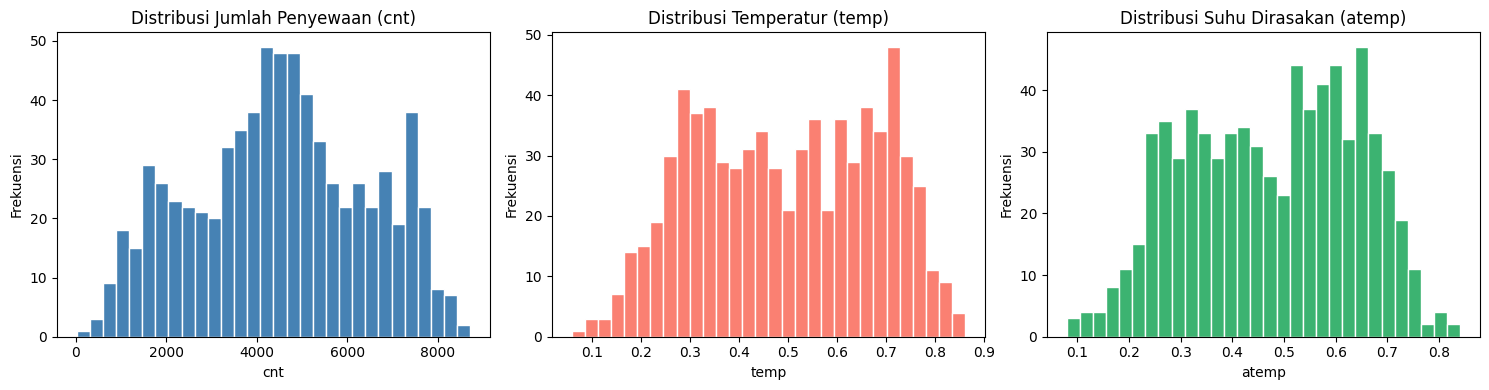

Skewness cnt : -0.047
Kurtosis cnt : -0.812
Skewness temp: -0.055
Skewness atemp: -0.131


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_day['cnt'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Jumlah Penyewaan (cnt)')
axes[0].set_xlabel('cnt')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(df_day['temp'], bins=30, color='salmon', edgecolor='white')
axes[1].set_title('Distribusi Temperatur (temp)')
axes[1].set_xlabel('temp')
axes[1].set_ylabel('Frekuensi')

axes[2].hist(df_day['atemp'], bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Distribusi Suhu Dirasakan (atemp)')
axes[2].set_xlabel('atemp')
axes[2].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

print('Skewness cnt :', round(df_day['cnt'].skew(), 3))
print('Kurtosis cnt :', round(df_day['cnt'].kurt(), 3))
print('Skewness temp:', round(df_day['temp'].skew(), 3))
print('Skewness atemp:', round(df_day['atemp'].skew(), 3))

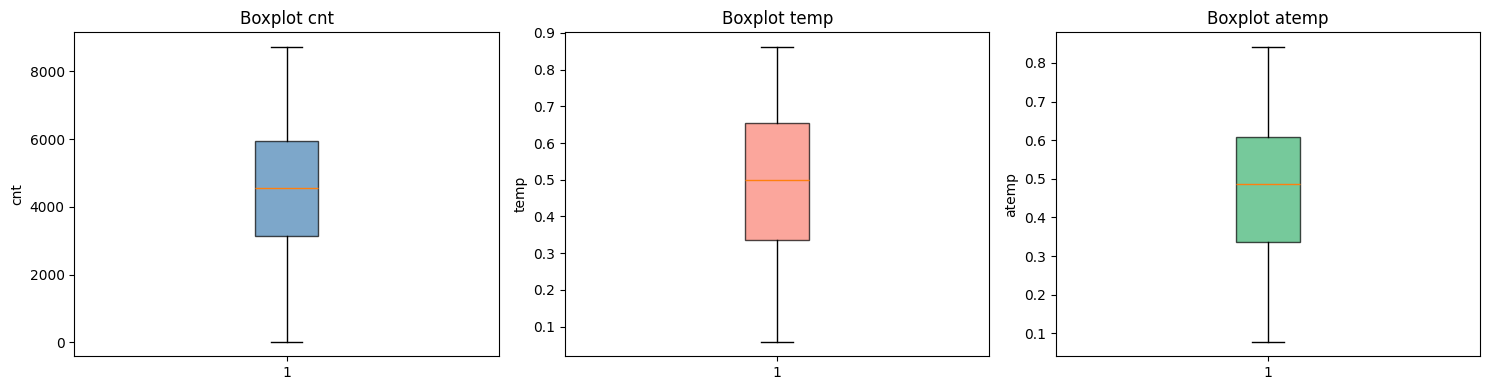

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cols  = ['cnt', 'temp', 'atemp']
colors = ['steelblue', 'salmon', 'mediumseagreen']
for ax, col, color in zip(axes, cols, colors):
    ax.boxplot(df_day[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7))
    ax.set_title(f'Boxplot {col}')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

### EDA Multivariate: Korelasi & Hubungan Antar Variabel

Menganalisis hubungan antar variabel numerik menggunakan correlation heatmap dan scatter plot dengan regression line, untuk mengidentifikasi variabel yang paling berpengaruh terhadap jumlah penyewaan (`cnt`).

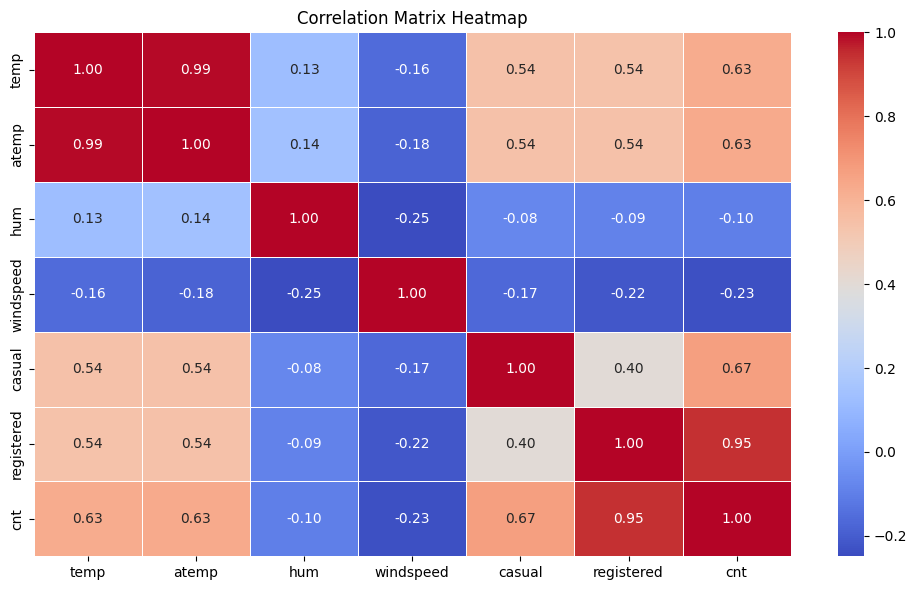

In [16]:
plt.figure(figsize=(10, 6))
numeric_cols = df_day[['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']]
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

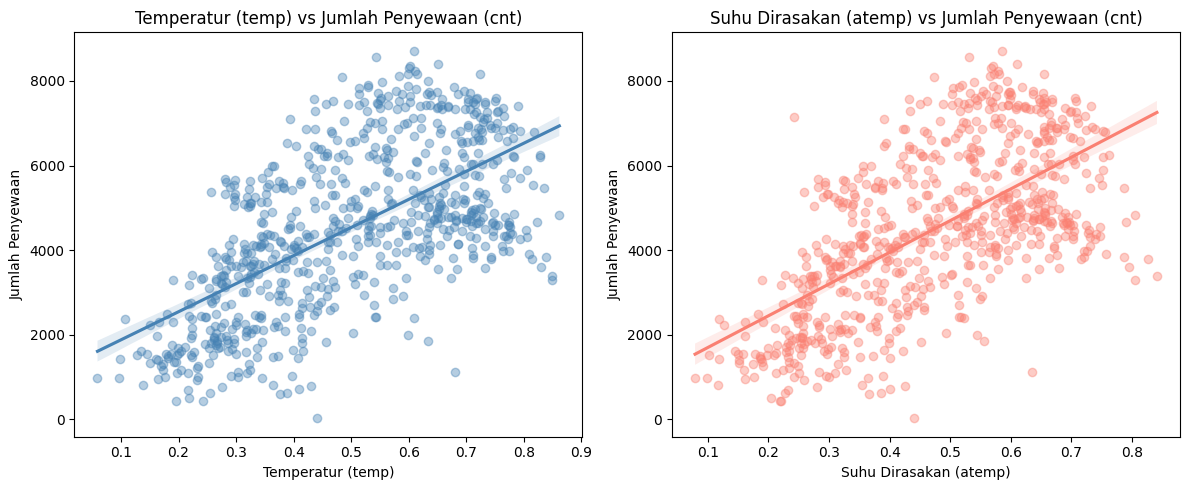

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.regplot(x='temp', y='cnt', data=df_day, ax=axes[0], color='steelblue',
            scatter_kws={'alpha': 0.4})
axes[0].set_title('Temperatur (temp) vs Jumlah Penyewaan (cnt)')
axes[0].set_xlabel('Temperatur (temp)')
axes[0].set_ylabel('Jumlah Penyewaan')

sns.regplot(x='atemp', y='cnt', data=df_day, ax=axes[1], color='salmon',
            scatter_kws={'alpha': 0.4})
axes[1].set_title('Suhu Dirasakan (atemp) vs Jumlah Penyewaan (cnt)')
axes[1].set_xlabel('Suhu Dirasakan (atemp)')
axes[1].set_ylabel('Jumlah Penyewaan')

plt.tight_layout()
plt.show()

### EDA Kategorikal: Distribusi Penyewaan per Kategori

Menganalisis bagaimana variabel kategorikal (musim) mempengaruhi distribusi jumlah penyewaan. Violin plot digunakan untuk melihat distribusi sekaligus outlier per kategori musim.

/tmp/ipykernel_6791/211204766.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='season_label', y='cnt', data=df_day, palette='Set2',


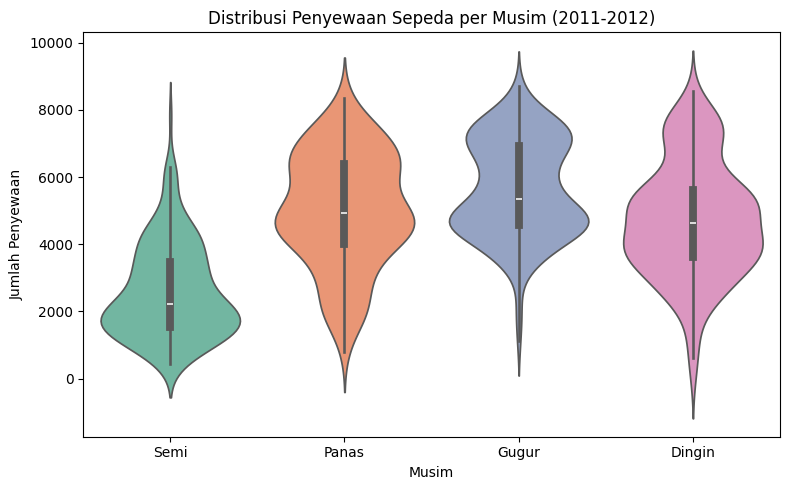

In [18]:
df_day['season_label'] = df_day['season'].map({1:'Semi', 2:'Panas', 3:'Gugur', 4:'Dingin'})

plt.figure(figsize=(8, 5))
sns.violinplot(x='season_label', y='cnt', data=df_day, palette='Set2',
               order=['Semi', 'Panas', 'Gugur', 'Dingin'])
plt.title('Distribusi Penyewaan Sepeda per Musim (2011-2012)')
plt.xlabel('Musim')
plt.ylabel('Jumlah Penyewaan')
plt.tight_layout()
plt.show()

In [19]:
percentiles = [5, 10, 25, 50, 75, 90, 95]
print('Percentile Analysis - cnt:')
for p in percentiles:
    print(f'  {p}th percentile: {df_day["cnt"].quantile(p/100):.0f}')

print('\nVariance cnt :', round(df_day['cnt'].var(), 2))
print('Std Dev cnt  :', round(df_day['cnt'].std(), 2))

Percentile Analysis - cnt:
  5th percentile: 1331
  10th percentile: 1746
  25th percentile: 3152
  50th percentile: 4548
  75th percentile: 5956
  90th percentile: 7290
  95th percentile: 7576

Variance cnt : 3752788.21
Std Dev cnt  : 1937.21


**Insight EDA:**

**Univariate:**
- Distribusi `cnt` cenderung simetris dengan sedikit right-skew, menunjukkan sebagian besar hari memiliki penyewaan moderat dengan beberapa hari puncak yang tinggi.
- Distribusi `temp` dan `atemp` hampir seragam (uniform), artinya data mencakup semua kondisi suhu secara merata sepanjang 2011-2012.
- Terdapat beberapa outlier pada `cnt` di nilai rendah, kemungkinan hari-hari dengan cuaca ekstrem.

**Multivariate:**
- `atemp` memiliki korelasi positif tertinggi terhadap `cnt` (0.63), diikuti `temp` (0.63).
- `hum` dan `windspeed` berkorelasi negatif dengan `cnt`, artinya kelembapan tinggi dan angin kencang menurunkan jumlah penyewaan.
- `temp` dan `atemp` berkorelasi sangat tinggi satu sama lain (0.99), sehingga keduanya merepresentasikan informasi yang hampir sama.

**Kategorikal:**
- Musim **Gugur** dan **Panas** memiliki median penyewaan tertinggi, sedangkan musim **Semi** terendah.
- Persebaran data (IQR) paling lebar di musim Panas, menunjukkan variabilitas penyewaan yang lebih tinggi di musim tersebut.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pada bulan apa penyewaan sepeda paling tinggi dan paling rendah (2011-2012)?

Menggunakan bar chart horizontal untuk membandingkan total/rata-rata penyewaan per bulan. Mapping label dilakukan terlebih dahulu agar visualisasi lebih mudah dibaca.

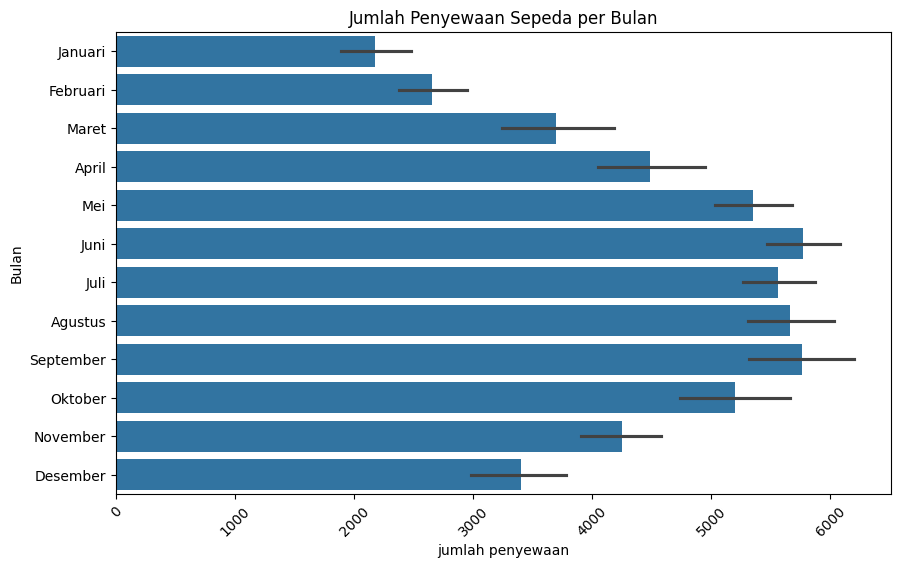

In [20]:
df_day['mnth'] = df_day['mnth'].map({
    1:'Januari', 2:'Februari', 3:'Maret', 4:'April',
    5:'Mei', 6:'Juni', 7:'Juli', 8:'Agustus',
    9:'September', 10:'Oktober', 11:'November', 12:'Desember'
})

plt.figure(figsize=(10, 6))
sns.barplot(x='cnt', y='mnth', data=df_day, order=['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember'])
plt.title('Jumlah Penyewaan Sepeda per Bulan')
plt.xlabel('jumlah penyewaan')
plt.ylabel('Bulan')
plt.xticks(rotation=45)
plt.show()

### Pertanyaan 2: Seberapa besar pengaruh suhu yang dirasakan tubuh (atemp) terhadap penyewaan (2011-2012)?

Suhu `atemp` (skala 0-1) dikonversi ke skala Celsius (×50) lalu dikategorikan ke 5 kelompok dengan teknik binning: Sangat Dingin (0-10°C), Dingin (10-20°C), Hangat (20-30°C), Panas (30-40°C), Sangat Panas (40-50°C).

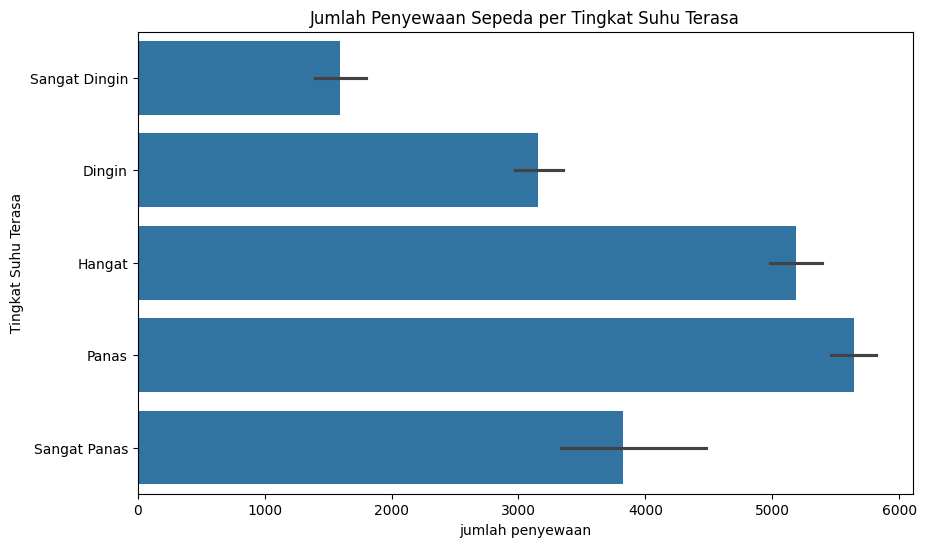

In [21]:
atemp_labels = ['Sangat Dingin','Dingin','Hangat','Panas','Sangat Panas']
df_day['atemp_category'] = pd.cut(df_day['atemp']*50,
  bins=[0, 10, 20, 30, 40, 50],
  labels=atemp_labels)

plt.figure(figsize=(10, 6))
sns.barplot(x='cnt', y='atemp_category', data=df_day, order=atemp_labels)
plt.title('Jumlah Penyewaan Sepeda per Tingkat Suhu Terasa')
plt.xlabel('jumlah penyewaan')
plt.ylabel('Tingkat Suhu Terasa')
plt.show()

**Insight Visualization & Explanatory Analysis:**

**Pertanyaan 1 — Penyewaan per Bulan:**
- Penyewaan **tertinggi** terjadi pada bulan **September** — bertepatan dengan akhir musim panas/awal gugur di mana suhu masih nyaman untuk bersepeda.
- Penyewaan **terendah** terjadi pada bulan **Januari** — musim dingin dengan suhu rendah membuat orang enggan bersepeda.
- Pola menunjukkan tren musiman yang jelas: penyewaan meningkat dari Maret hingga September, kemudian menurun.

**Pertanyaan 2 — Pengaruh Suhu:**
- Penyewaan tertinggi terjadi pada kategori suhu **Panas (30-40°C)**, diikuti **Hangat (20-30°C)**.
- Kategori **Sangat Dingin (0-10°C)** memiliki penyewaan paling rendah.
- Terdapat hubungan **positif kuat** antara suhu yang dirasakan dengan jumlah penyewaan — semakin hangat, semakin banyak orang menyewa sepeda.
- Namun pada suhu **Sangat Panas (>40°C)**, penyewaan mulai sedikit menurun, kemungkinan karena terlalu panas untuk beraktivitas.

## Analisis Lanjutan: Clustering dengan Binning

Melakukan pengelompokan (clustering) hari-hari penyewaan berdasarkan kondisi cuaca dan suhu menggunakan teknik **binning**. Tujuannya adalah mengidentifikasi kategori hari berdasarkan 'kelayakan bersepeda' tanpa algoritma machine learning, untuk memberikan rekomendasi operasional bisnis yang lebih terarah.

### Clustering 1: Kelayakan Hari untuk Bersepeda (Binning Multi-Variabel)

Mengelompokkan setiap hari ke dalam 3 kategori kelayakan bersepeda berdasarkan kombinasi:
- **Suhu** (`atemp`): nyaman jika 0.3–0.75 (≈ 15–37°C)
- **Kelembapan** (`hum`): nyaman jika < 0.8
- **Kecepatan angin** (`windspeed`): nyaman jika < 0.4

Kategori hasil: `Ideal`, `Cukup`, `Tidak Ideal`

In [22]:
def classify_day(row):
    score = 0
    if 0.3 <= row['atemp'] <= 0.75:
        score += 1
    if row['hum'] < 0.8:
        score += 1
    if row['windspeed'] < 0.4:
        score += 1

    if score == 3:
        return 'Ideal'
    elif score == 2:
        return 'Cukup'
    else:
        return 'Tidak Ideal'

df_day['bike_condition'] = df_day.apply(classify_day, axis=1)

condition_counts = df_day['bike_condition'].value_counts().reindex(['Ideal', 'Cukup', 'Tidak Ideal'])
print('Distribusi Kelayakan Hari:')
print(condition_counts)
print(f'\nTotal hari: {len(df_day)}')

Distribusi Kelayakan Hari:
bike_condition
Ideal          497
Cukup          219
Tidak Ideal     15
Name: count, dtype: int64

Total hari: 731


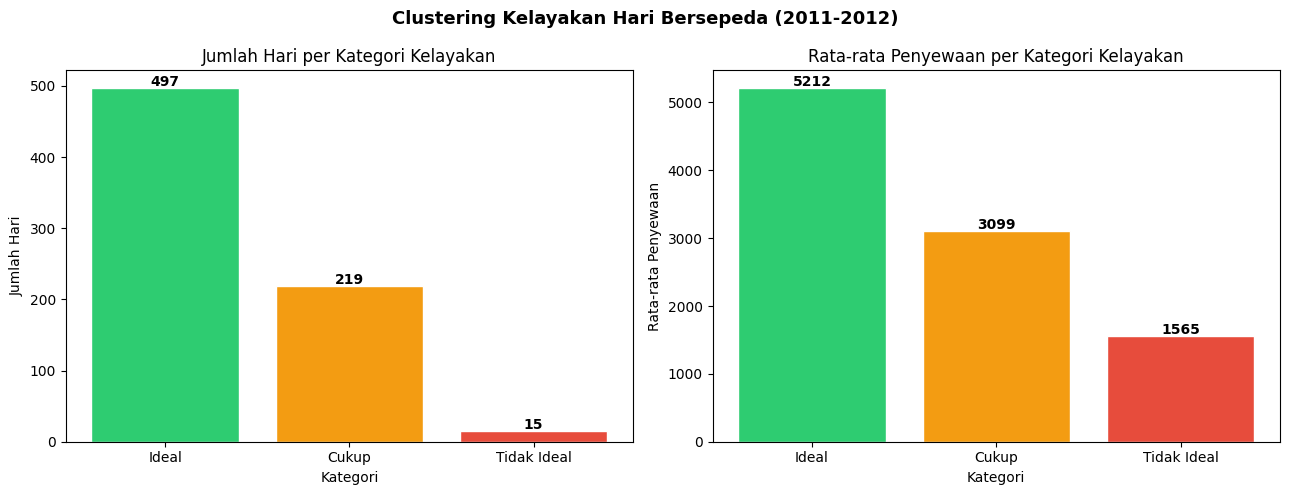


Rata-rata penyewaan per kategori:
bike_condition
Ideal          5212.0
Cukup          3099.0
Tidak Ideal    1565.0
Name: cnt, dtype: float64


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_cond = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(condition_counts.index, condition_counts.values, color=colors_cond, edgecolor='white')
axes[0].set_title('Jumlah Hari per Kategori Kelayakan')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah Hari')
for i, v in enumerate(condition_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

avg_by_condition = df_day.groupby('bike_condition', observed=True)['cnt'].mean().reindex(['Ideal', 'Cukup', 'Tidak Ideal'])
axes[1].bar(avg_by_condition.index, avg_by_condition.values, color=colors_cond, edgecolor='white')
axes[1].set_title('Rata-rata Penyewaan per Kategori Kelayakan')
axes[1].set_xlabel('Kategori')
axes[1].set_ylabel('Rata-rata Penyewaan')
for i, v in enumerate(avg_by_condition.values):
    axes[1].text(i, v + 30, f'{v:.0f}', ha='center', fontweight='bold')

plt.suptitle('Clustering Kelayakan Hari Bersepeda (2011-2012)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nRata-rata penyewaan per kategori:')
print(avg_by_condition.round(0))

### Clustering 2: Segmentasi Intensitas Penyewaan Harian (Binning cnt)

Mengelompokkan hari-hari berdasarkan **volume penyewaan** menggunakan binning pada kolom `cnt`:
- **Sepi**: < 2.000 penyewaan/hari
- **Normal**: 2.000–5.500 penyewaan/hari
- **Ramai**: 5.500–7.500 penyewaan/hari
- **Sangat Ramai**: > 7.500 penyewaan/hari

Analisis ini membantu bisnis merencanakan kebutuhan armada dan staf secara lebih presisi.

In [24]:
df_day['rental_segment'] = pd.cut(
    df_day['cnt'],
    bins=[0, 2000, 5500, 7500, 10000],
    labels=['Sepi', 'Normal', 'Ramai', 'Sangat Ramai']
)

segment_counts = df_day['rental_segment'].value_counts().reindex(['Sepi', 'Normal', 'Ramai', 'Sangat Ramai'])
print('Distribusi Segmen Penyewaan:')
print(segment_counts)
print(f'\nPersentase:')
print((segment_counts / len(df_day) * 100).round(1).astype(str) + '%')

Distribusi Segmen Penyewaan:
rental_segment
Sepi             98
Normal          410
Ramai           178
Sangat Ramai     45
Name: count, dtype: int64

Persentase:
rental_segment
Sepi            13.4%
Normal          56.1%
Ramai           24.4%
Sangat Ramai     6.2%
Name: count, dtype: object


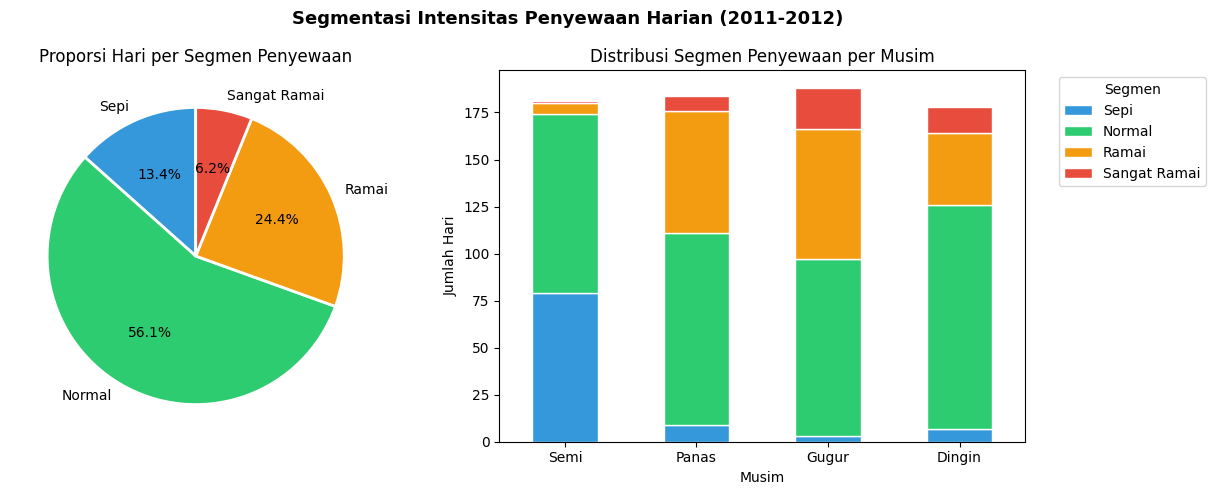

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

seg_colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
order_seg = ['Sepi', 'Normal', 'Ramai', 'Sangat Ramai']

axes[0].pie(
    segment_counts.values,
    labels=order_seg,
    colors=seg_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Proporsi Hari per Segmen Penyewaan')

if 'season_label' not in df_day.columns:
    df_day['season_label'] = df_day['season'].map({1:'Semi', 2:'Panas', 3:'Gugur', 4:'Dingin'})

season_seg = df_day.groupby(['season_label', 'rental_segment'], observed=True).size().unstack(fill_value=0)
season_seg = season_seg.reindex(columns=order_seg, fill_value=0)
season_order = ['Semi', 'Panas', 'Gugur', 'Dingin']
season_seg = season_seg.reindex(season_order)
season_seg.plot(kind='bar', stacked=True, ax=axes[1], color=seg_colors, edgecolor='white')
axes[1].set_title('Distribusi Segmen Penyewaan per Musim')
axes[1].set_xlabel('Musim')
axes[1].set_ylabel('Jumlah Hari')
axes[1].legend(title='Segmen', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Segmentasi Intensitas Penyewaan Harian (2011-2012)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight Analisis Lanjutan:**

**Clustering 1 — Kelayakan Hari Bersepeda:**
- Sebagian besar hari (mayoritas) masuk kategori **Ideal** atau **Cukup**, artinya kondisi cuaca di lokasi dataset umumnya mendukung aktivitas bersepeda.
- Hari **Ideal** memiliki rata-rata penyewaan jauh lebih tinggi dibanding hari **Tidak Ideal**, membuktikan bahwa kondisi cuaca sangat berpengaruh terhadap keputusan pengguna untuk menyewa sepeda.
- Ini mengkonfirmasi temuan di Pertanyaan 2: suhu, kelembapan, dan angin secara bersama-sama menentukan volume penyewaan.

**Clustering 2 — Segmentasi Intensitas Penyewaan:**
- Segmen **Normal** mendominasi (>50% hari), menunjukkan bisnis berjalan stabil di sebagian besar waktu.
- Segmen **Sangat Ramai** terkonsentrasi di musim **Panas** dan **Gugur** — ini adalah periode paling kritis untuk kesiapan armada.
- Segmen **Sepi** paling banyak terjadi di musim **Semi** dan **Dingin** — periode yang tepat untuk perawatan armada dan kampanye promosi.
- Insight ini dapat digunakan untuk **perencanaan operasional**: tambah armada di musim Panas-Gugur, jadwalkan maintenance di musim Dingin-Semi.

## Conclusion & Recommendation

**Conclusion Pertanyaan 1:**
Berdasarkan analisis data periode 2011-2012, penyewaan sepeda **tertinggi** terjadi pada bulan **September** yang bertepatan dengan akhir musim panas/awal musim gugur — kondisi suhu paling nyaman untuk bersepeda. Sebaliknya, penyewaan **terendah** terjadi di bulan **Januari** saat musim dingin dengan suhu sangat rendah. Pola musiman ini konsisten di tahun 2011 maupun 2012.

**Conclusion Pertanyaan 2:**
Terdapat pengaruh **positif dan kuat** antara suhu yang dirasakan tubuh (atemp) dengan jumlah penyewaan sepeda (korelasi 0.63). Penyewaan tertinggi terjadi pada rentang suhu **Panas (30-40°C)** dan **Hangat (20-30°C)**, yaitu sekitar bulan April hingga September. Pada suhu sangat dingin (<10°C), penyewaan turun drastis.

**Rekomendasi Action Item:**

Berdasarkan kedua kesimpulan di atas, berikut rekomendasi bisnis yang dapat diterapkan:

1. **Strategi Promosi Musim Rendah (Januari-Maret):** Tawarkan diskon atau paket bundling (sewa sepeda + jaket/perlengkapan hangat) untuk mendorong penyewaan di bulan-bulan dingin yang sepi.

2. **Strategi Puncak Musim (Juni-September):** Tambah armada sepeda dan pastikan ketersediaan unit optimal di bulan-bulan puncak untuk memaksimalkan pendapatan. Lakukan perawatan armada di bulan Januari-Februari saat permintaan rendah.

3. **Strategi Berbasis Suhu:** Terapkan dynamic pricing — harga sedikit lebih tinggi saat suhu berada di rentang nyaman (20-40°C) dan tawarkan promosi saat suhu ekstrem (sangat dingin atau sangat panas) untuk menjaga volume penyewaan tetap stabil.

In [26]:
df_day.to_csv('main_data.csv', index=False)